In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

### Load Solutions

In [2]:
def load_solutions(filepath):
    solutions = {}
    with open(filepath, encoding='utf-8') as f:
        content = f.read()
    blocks = content.strip().split('----------------------------------------')
    for block in blocks:
        date_m = re.search(r'Date:\s*(\d{4}-\d{2}-\d{2})', block)
        if not date_m:
            continue
        date = date_m.group(1).replace('-', '_')
        sol_section = block.split('Solution:')[-1]
        letters = re.findall(r'[A-Z]', sol_section)
        solutions[date] = ''.join(letters)
    return solutions

solutions = load_solutions('monday_solutions.txt')

### Load Ranking Method Folders

In [3]:
def parse_log(filepath, solution):
    df = pd.read_csv(filepath)
    actions = df['action'].value_counts().to_dict()

    reported_solved = 'failed_solve' not in df['action'].values
    backtracks = actions.get('backtrack', 0)

    grids = df[df['action'] == 'print_grid']['message']
    grid_letters = ''.join(re.findall(r'[A-Z]', grids.iloc[-1])) if len(grids) > 0 else ''

    if solution:
        min_len = min(len(grid_letters), len(solution))
        matches = sum(g == s for g, s in zip(grid_letters[:min_len], solution[:min_len]))
        letter_acc = (matches / len(solution) * 100) if len(solution) > 0 else 0.0
        truly_solved = grid_letters == solution
    else:
        letter_acc = 0.0
        truly_solved = False

    return {
        'backtracks': backtracks,
        'reported_solved': reported_solved,
        'truly_solved': truly_solved,
        'false_positive': reported_solved and not truly_solved,
        'letter_accuracy': round(letter_acc, 1)
    }


def load_folder(folder, solutions):
    rows = []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith('.csv'):
            continue
        date_m = re.search(r'(\d{4}_\d{2}_\d{2})', fname)
        date = date_m.group(1) if date_m else fname.replace('.csv', '')
        sol = solutions.get(date, '')
        result = parse_log(os.path.join(folder, fname), sol)
        result['date'] = date
        rows.append(result)
    return pd.DataFrame(rows)

In [8]:
# ── Set your folder paths here ──────────────────────────────
none_folder = 'crosswords_none'
vc_folder   = 'Vagueness-and-Complexity'
vcl_folder  = 'Vagueness-and-Complexity-Plus-Known-Letters'
# ────────────────────────────────────────────────────────────

none_df = load_folder(none_folder, solutions)
vc_df   = load_folder(vc_folder,   solutions)
vcl_df  = load_folder(vcl_folder,  solutions)

none_df['method'] = 'None'
vc_df['method']   = 'Vagueness and Complexity'
vcl_df['method']  = 'Vagueness and Complexity\n with Known Letters'

all_df = pd.concat([none_df, vc_df, vcl_df], ignore_index=True)
all_df.shape

(132, 7)

### Graph 1 — Average Backtracks per Ranking Method

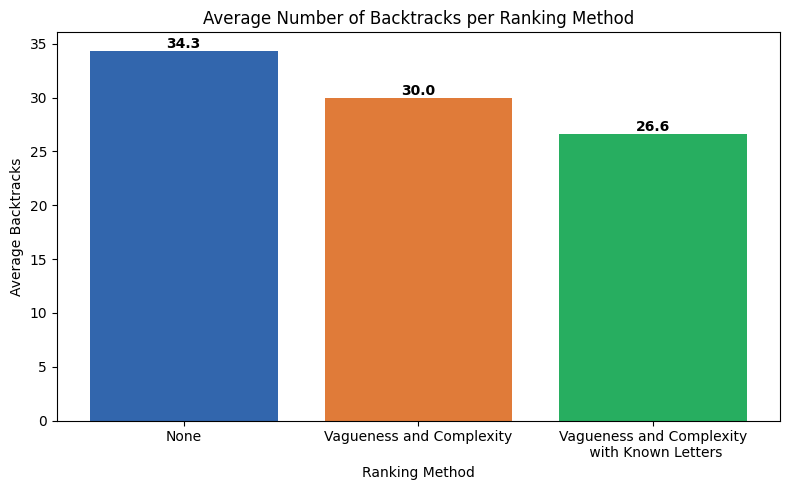

In [9]:
avg_bt = all_df.groupby('method')['backtracks'].mean().reset_index(name='avg_backtracks')

plt.figure(figsize=(8, 5))
plt.bar(avg_bt['method'], avg_bt['avg_backtracks'], color=['#3266ad', '#e07b39', '#27ae60'])

plt.xlabel('Ranking Method')
plt.ylabel('Average Backtracks')
plt.title('Average Number of Backtracks per Ranking Method')

for i, v in enumerate(avg_bt['avg_backtracks']):
    plt.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('1_avg_backtracks.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 2 — Solve Rate per Ranking Method (including false positives)

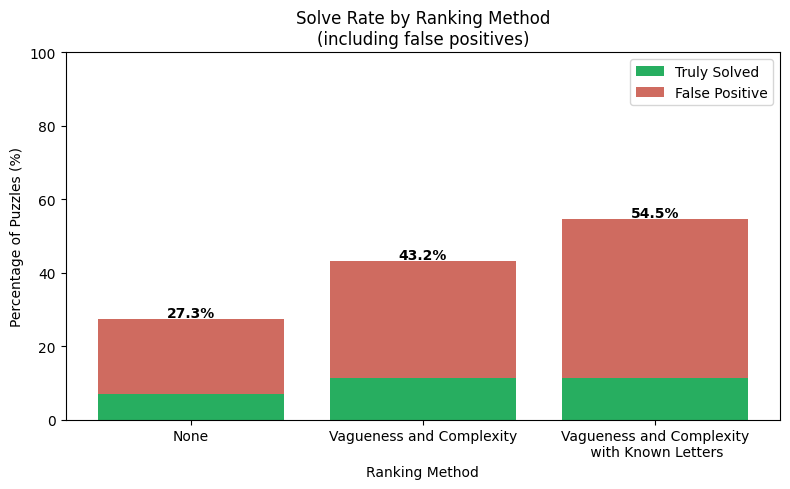

In [11]:
solve_rate = all_df.groupby('method').agg(
    total=('truly_solved', 'count'),
    truly_solved=('truly_solved', 'sum'),
    false_positives=('false_positive', 'sum')
).reset_index()

solve_rate['true_pct'] = solve_rate['truly_solved']    / solve_rate['total'] * 100
solve_rate['fp_pct']   = solve_rate['false_positives'] / solve_rate['total'] * 100

methods = solve_rate['method']

plt.figure(figsize=(8, 5))
plt.bar(methods, solve_rate['true_pct'], color='#27ae60', label='Truly Solved')
plt.bar(methods, solve_rate['fp_pct'],   color='#c0392b', alpha=0.75,
        bottom=solve_rate['true_pct'],   label='False Positive')

for i, row in solve_rate.iterrows():
    total = row['true_pct'] + row['fp_pct']
    plt.text(i, total + 0.5, f"{total:.1f}%", ha='center', fontweight='bold')

plt.xlabel('Ranking Method')
plt.ylabel('Percentage of Puzzles (%)')
plt.title('Solve Rate by Ranking Method\n(including false positives)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.savefig('2_solve_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 3 — Letter Accuracy per Ranking Method

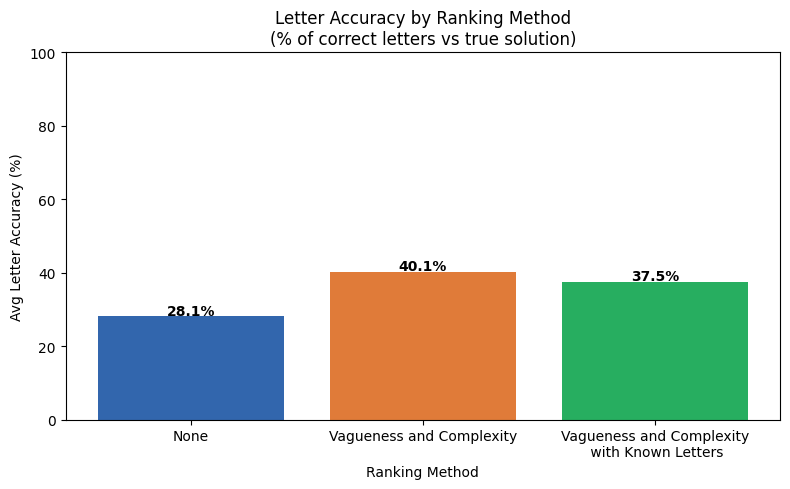

In [12]:
letter_acc = all_df.groupby('method')['letter_accuracy'].mean().reset_index(name='avg_letter_accuracy')

plt.figure(figsize=(8, 5))
plt.bar(letter_acc['method'], letter_acc['avg_letter_accuracy'],
        color=['#3266ad', '#e07b39', '#27ae60'])

plt.xlabel('Ranking Method')
plt.ylabel('Avg Letter Accuracy (%)')
plt.title('Letter Accuracy by Ranking Method\n(% of correct letters vs true solution)')
plt.ylim(0, 100)

for i, v in enumerate(letter_acc['avg_letter_accuracy']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('3_letter_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()